# DistilBERT (Colab) — Final Test (Training Size Sweep)

This notebook runs a benchmark sweep over different train-set sizes while keeping model/training configuration fixed.

Fixed config:

- model: `distilbert-base-uncased`, `problem_type='multi_label_classification'`
- data split: `validation_fraction=0.1`, `random_state=42`, `use_iterative_stratify=True`, `rebalance_train=False`
- tokenization: `max_length=128`, padding/truncation to max length
- training: `batch_size=32`, `gradient_accumulation_steps=1`, `max_epochs=5`
- optimization: `AdamW`, `learning_rate=1.75e-5`, `weight_decay=0.015`, `linear_with_warmup`, `warmup_ratio=0.1`
- regularization: early stopping on validation loss (`patience=2`, `min_delta=0.0`, restore best weights)
- loss: `BCEWithLogitsLoss` with `pos_weight=None`
- precision/perf: bf16 mixed precision if supported, `torch_compile=False`
- dataloader: `num_workers=2`
- evaluation: per-label tuned thresholds on `np.arange(0.05, 0.951, 0.01)`
- reproducibility: torch/numpy seed = 42

In [ ]:
# Colab setup: install dependencies
!pip -q install torch transformers pandas numpy matplotlib scikit-learn seaborn iterative-stratification

In [ ]:
# Mount Google Drive and set paths
from pathlib import Path
import os
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

# ===== CHANGE THIS to your repo folder in Drive =====
PROJECT_ROOT = Path('/content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil')

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(
        f'PROJECT_ROOT not found: {PROJECT_ROOT}. Upload/clone your repo to this path first.'
    )

NOTEBOOKS_DIR = PROJECT_ROOT / 'notebooks'
ARTIFACT_DIR = NOTEBOOKS_DIR / 'artifacts_colab_final_train_size_sweep'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(NOTEBOOKS_DIR))

print('PROJECT_ROOT:', PROJECT_ROOT)
print('ARTIFACT_DIR:', ARTIFACT_DIR)

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil
ARTIFACT_DIR: /content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil/notebooks/artifacts_colab_final_train_size_sweep


In [ ]:
import contextlib
import math
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from sklearn.metrics import confusion_matrix, f1_score

from preprocessing.text_preprocessing import LABEL_COLUMNS, preprocess_for_distilbert
from metrics_helpers import multilabel_evaluation_report, torch_parameter_count

os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')


def pick_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


def binary_f1(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    denom = 2 * tp + fp + fn
    return float((2 * tp) / denom) if denom > 0 else 0.0


def tune_per_label_thresholds(y_true: np.ndarray, y_prob: np.ndarray, labels, threshold_grid: np.ndarray):
    best_thresholds = {}
    rows = []
    for j, label in enumerate(labels):
        y_true_j = y_true[:, j]
        y_prob_j = y_prob[:, j]
        best_t = 0.5
        best_f1 = -1.0
        for t in threshold_grid:
            y_pred_j = (y_prob_j >= t).astype(np.int64)
            f1_j = binary_f1(y_true_j, y_pred_j)
            if f1_j > best_f1:
                best_f1 = f1_j
                best_t = float(t)
        best_thresholds[label] = best_t
        rows.append({'label': label, 'best_threshold': round(best_t, 3), 'best_f1_on_val': best_f1})
    return best_thresholds, pd.DataFrame(rows)


def apply_thresholds(y_prob: np.ndarray, labels, thresholds: dict[str, float]) -> np.ndarray:
    out = np.zeros_like(y_prob, dtype=np.int64)
    for j, label in enumerate(labels):
        out[:, j] = (y_prob[:, j] >= thresholds[label]).astype(np.int64)
    return out


def make_confusion_artifacts(y_true: np.ndarray, y_pred: np.ndarray, labels):
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = np.asarray(y_pred, dtype=np.int64)

    per_label_rows = []
    for j, label in enumerate(labels):
        cm = confusion_matrix(y_true[:, j], y_pred[:, j], labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        per_label_rows.append({'label': label, 'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp)})

    per_label_df = pd.DataFrame(per_label_rows)

    agg_cm = confusion_matrix(y_true.ravel(), y_pred.ravel(), labels=[0, 1])
    agg_tn, agg_fp, agg_fn, agg_tp = agg_cm.ravel()
    aggregate_df = pd.DataFrame([
        {'tn': int(agg_tn), 'fp': int(agg_fp), 'fn': int(agg_fn), 'tp': int(agg_tp)}
    ])

    return per_label_df, aggregate_df, agg_cm


class EncDataset(Dataset):
    def __init__(self, enc, labels):
        self.enc = enc
        self.labels = torch.tensor(labels, dtype=torch.float32)

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.enc.items()}
        item['labels'] = self.labels[i]
        return item


def collate(batch):
    out = {k: torch.stack([b[k] for b in batch], dim=0) for k in batch[0] if k != 'labels'}
    out['labels'] = torch.stack([b['labels'] for b in batch], dim=0)
    return out


def enc_dict(enc):
    keys = [k for k in ('input_ids', 'attention_mask') if k in enc]
    return {k: enc[k] for k in keys}

In [ ]:
# Final configuration + training-size sweep setup
DEVICE = pick_device()
if DEVICE.type == 'cuda':
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

torch.manual_seed(42)
np.random.seed(42)

# model
MODEL_NAME = 'distilbert-base-uncased'
PROBLEM_TYPE = 'multi_label_classification'

# data
VALIDATION_FRACTION = 0.1
RANDOM_STATE = 42
USE_ITERATIVE_STRATIFY = True
REBALANCE_TRAIN = False

# tokenization
MAX_LENGTH = 128

# training
BATCH_SIZE = 32
GRADIENT_ACCUMULATION_STEPS = 1
MAX_EPOCHS = 5
LR = 1.75e-5
WEIGHT_DECAY = 0.015
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0

# regularization
EARLY_STOP_ENABLED = True
EARLY_STOP_PATIENCE = 2
EARLY_STOP_MIN_DELTA = 0.0

# loss
USE_POS_WEIGHT = False

# precision/perf
USE_BF16 = True
USE_TORCH_COMPILE = False

# dataloader
NUM_WORKERS = 2

# evaluation
THRESHOLD_GRID = np.arange(0.05, 0.951, 0.01)

# reproducibility
TORCH_SEED = 42
NUMPY_SEED = 42

# sweep controls
SIZE_STEP = 10000
MAX_VAL_SAMPLES = None
SKIP_COMPLETED = True

_bf16_ok = DEVICE.type == 'cuda' and torch.cuda.is_bf16_supported()
USE_AMP = bool(USE_BF16 and _bf16_ok)
if USE_BF16 and DEVICE.type == 'cuda' and not _bf16_ok:
    print('USE_BF16 requested but bf16 not supported on this GPU; training in full precision.')

print('Device:', DEVICE)
print('AMP (bf16):', USE_AMP)
print('TF32 enabled on CUDA:', DEVICE.type == 'cuda')
print('Size step:', SIZE_STEP)

Device: cuda
AMP (bf16): True
TF32 enabled on CUDA: True
Size step: 10000


In [ ]:
# Run final benchmark sweep across training sizes
summary_rows = []
per_label_frames = []
threshold_frames = []
conf_per_label_base_frames = []
conf_per_label_tuned_frames = []
conf_agg_base_rows = []
conf_agg_tuned_rows = []

pin = DEVICE.type == 'cuda'

torch.manual_seed(TORCH_SEED)
np.random.seed(NUMPY_SEED)

# Determine full train size after split (before train-size cap)
full_data = preprocess_for_distilbert(
    validation_fraction=VALIDATION_FRACTION,
    random_state=RANDOM_STATE,
    max_length=MAX_LENGTH,
    return_tensors='pt',
    max_train_samples=None,
    max_val_samples=MAX_VAL_SAMPLES,
    use_iterative_stratify=USE_ITERATIVE_STRATIFY,
    rebalance_train=REBALANCE_TRAIN,
    rebalance_random_state=RANDOM_STATE,
    print_diagnostics=True,
)
full_train_count = int(np.asarray(full_data.y_train).shape[0])
print('Full train rows after split:', full_train_count)

del full_data

if full_train_count <= SIZE_STEP:
    train_sizes = [full_train_count]
else:
    train_sizes = list(range(SIZE_STEP, full_train_count + 1, SIZE_STEP))
    if train_sizes[-1] != full_train_count:
        train_sizes.append(full_train_count)

run_specs = []
for train_size in train_sizes:
    frac = float(train_size) / float(full_train_count)
    run_specs.append({
        'train_size': int(train_size),
        'train_fraction': frac,
        'max_train_samples': int(train_size),
    })

print('train_sizes:', train_sizes[:5], '...', train_sizes[-1], f'(n={len(train_sizes)})')

for idx, spec in enumerate(run_specs, start=1):
    run_id = f"train_size_{spec['train_size']}"
    row_file = ARTIFACT_DIR / f'summary_{run_id}.csv'
    per_label_file = ARTIFACT_DIR / f'per_label_{run_id}.csv'
    thresholds_file = ARTIFACT_DIR / f'thresholds_{run_id}.csv'
    conf_per_label_base_file = ARTIFACT_DIR / f'confusion_per_label_baseline_{run_id}.csv'
    conf_per_label_tuned_file = ARTIFACT_DIR / f'confusion_per_label_tuned_{run_id}.csv'
    conf_agg_base_file = ARTIFACT_DIR / f'confusion_aggregate_baseline_{run_id}.csv'
    conf_agg_tuned_file = ARTIFACT_DIR / f'confusion_aggregate_tuned_{run_id}.csv'

    files_exist = all([
        row_file.exists(), per_label_file.exists(), thresholds_file.exists(),
        conf_per_label_base_file.exists(), conf_per_label_tuned_file.exists(),
        conf_agg_base_file.exists(), conf_agg_tuned_file.exists()
    ])

    if SKIP_COMPLETED and files_exist:
        try:
            print(f"[{idx}/{len(run_specs)}] {run_id}: skipping (already exists)")
            summary_rows.append(pd.read_csv(row_file).iloc[0].to_dict())
            per_label_frames.append(pd.read_csv(per_label_file))
            threshold_frames.append(pd.read_csv(thresholds_file))
            conf_per_label_base_frames.append(pd.read_csv(conf_per_label_base_file))
            conf_per_label_tuned_frames.append(pd.read_csv(conf_per_label_tuned_file))
            conf_agg_base_rows.append(pd.read_csv(conf_agg_base_file).iloc[0].to_dict())
            conf_agg_tuned_rows.append(pd.read_csv(conf_agg_tuned_file).iloc[0].to_dict())
            continue
        except OSError as e:
            print(f"[{idx}/{len(run_specs)}] {run_id}: Drive read failed ({e}); rerunning this spec.")

    print(
        f"[{idx}/{len(run_specs)}] {run_id}: running "
        f"(max_train_samples={spec['max_train_samples']}, frac={spec['train_fraction']:.4f})"
    )

    run_data = preprocess_for_distilbert(
        validation_fraction=VALIDATION_FRACTION,
        random_state=RANDOM_STATE,
        max_length=MAX_LENGTH,
        return_tensors='pt',
        max_train_samples=spec['max_train_samples'],
        max_val_samples=MAX_VAL_SAMPLES,
        use_iterative_stratify=USE_ITERATIVE_STRATIFY,
        rebalance_train=REBALANCE_TRAIN,
        rebalance_random_state=RANDOM_STATE,
        print_diagnostics=True,
    )

    train_enc = enc_dict(run_data.train_encodings)
    val_enc = enc_dict(run_data.val_encodings)
    y_train = np.asarray(run_data.y_train, dtype=np.float32)
    y_val = np.asarray(run_data.y_val, dtype=np.int64)

    train_loader = DataLoader(
        EncDataset(train_enc, y_train),
        batch_size=BATCH_SIZE,
        shuffle=True,
        collate_fn=collate,
        num_workers=NUM_WORKERS,
        pin_memory=pin,
        persistent_workers=NUM_WORKERS > 0,
    )
    val_loader = DataLoader(
        EncDataset(val_enc, y_val),
        batch_size=BATCH_SIZE,
        shuffle=False,
        collate_fn=collate,
        num_workers=NUM_WORKERS,
        pin_memory=pin,
        persistent_workers=NUM_WORKERS > 0,
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(LABEL_COLUMNS),
        problem_type=PROBLEM_TYPE,
    ).to(DEVICE)

    if USE_TORCH_COMPILE and hasattr(torch, 'compile'):
        try:
            model = torch.compile(model)  # type: ignore[assignment]
            print('  torch.compile enabled')
        except Exception as e:
            print('  torch.compile skipped:', e)

    num_params = torch_parameter_count(model)

    no_decay = ['bias', 'LayerNorm.weight']
    optimizer_grouped_parameters = [
        {
            'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
            'weight_decay': WEIGHT_DECAY,
        },
        {
            'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
            'weight_decay': 0.0,
        },
    ]
    optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=LR)

    def compute_loss(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        return F.binary_cross_entropy_with_logits(logits, labels)

    steps_per_epoch = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS)
    num_training_steps = steps_per_epoch * MAX_EPOCHS
    warmup_steps = int(WARMUP_RATIO * num_training_steps)
    warmup_steps = max(0, min(warmup_steps, num_training_steps - 1)) if num_training_steps > 0 else 0
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=num_training_steps
    )

    train_time_s = 0.0
    inference_time_s = 0.0
    train_loss_last = float('nan')
    val_loss_last = float('nan')

    best_val_loss = float('inf')
    best_state_cpu = None
    best_epoch = 0
    patience_left = EARLY_STOP_PATIENCE
    epochs_ran = 0
    early_stopped = False

    if USE_AMP:
        autocast_ctx = torch.autocast(device_type='cuda', dtype=torch.bfloat16, enabled=True)
    else:
        autocast_ctx = contextlib.nullcontext()

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        epoch_train_loss = 0.0
        epoch_batches = 0
        t0 = time.perf_counter()
        optimizer.zero_grad(set_to_none=True)
        micro = 0

        for batch in train_loader:
            batch = {k: v.to(DEVICE, non_blocking=pin) for k, v in batch.items()}
            labels = batch.pop('labels')
            with autocast_ctx:
                logits = model(**batch).logits
                loss = compute_loss(logits, labels) / GRADIENT_ACCUMULATION_STEPS
            loss.backward()
            micro += 1
            epoch_train_loss += float(loss.item()) * GRADIENT_ACCUMULATION_STEPS
            epoch_batches += 1

            if micro % GRADIENT_ACCUMULATION_STEPS == 0:
                if MAX_GRAD_NORM is not None:
                    torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad(set_to_none=True)

        if micro % GRADIENT_ACCUMULATION_STEPS != 0:
            if MAX_GRAD_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad(set_to_none=True)

        train_time_s += time.perf_counter() - t0
        train_loss_last = epoch_train_loss / max(epoch_batches, 1)

        model.eval()
        val_loss_sum = 0.0
        val_batches = 0
        t1 = time.perf_counter()
        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(DEVICE, non_blocking=pin) for k, v in batch.items()}
                labels = batch.pop('labels')
                with autocast_ctx:
                    logits = model(**batch).logits
                    vloss = compute_loss(logits, labels)
                val_loss_sum += float(vloss.item())
                val_batches += 1

        inference_time_s += time.perf_counter() - t1
        val_loss_last = val_loss_sum / max(val_batches, 1)
        epochs_ran = epoch

        improved = (best_val_loss - val_loss_last) > EARLY_STOP_MIN_DELTA
        if improved:
            best_val_loss = val_loss_last
            best_epoch = epoch
            patience_left = EARLY_STOP_PATIENCE
            best_state_cpu = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            if EARLY_STOP_ENABLED:
                patience_left -= 1
                if patience_left <= 0:
                    early_stopped = True
                    print(f'  early stop at epoch {epoch}')
                    break

        print(
            f"  epoch {epoch:02d} | train_loss={train_loss_last:.4f} | val_loss={val_loss_last:.4f} | "
            f"best_val={best_val_loss:.4f}"
        )

    if best_state_cpu is not None:
        model.load_state_dict(best_state_cpu)

    model.eval()
    probs_all = []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(DEVICE, non_blocking=pin) for k, v in batch.items()}
            _ = batch.pop('labels')
            with autocast_ctx:
                logits = model(**batch).logits
            probs_all.append(torch.sigmoid(logits).float().detach().cpu().numpy())

    y_prob = np.vstack(probs_all)
    y_pred_base = (y_prob >= 0.5).astype(np.int64)
    _, base_summary = multilabel_evaluation_report(y_val, y_pred_base, y_prob, LABEL_COLUMNS)

    best_thresholds, thresholds_df = tune_per_label_thresholds(y_val, y_prob, LABEL_COLUMNS, THRESHOLD_GRID)
    y_pred_tuned = apply_thresholds(y_prob, LABEL_COLUMNS, best_thresholds)
    per_label_df, tuned_summary = multilabel_evaluation_report(y_val, y_pred_tuned, y_prob, LABEL_COLUMNS)

    per_label_df.insert(0, 'train_size', spec['train_size'])
    per_label_df.insert(1, 'train_fraction', spec['train_fraction'])
    per_label_df.insert(2, 'max_train_samples', spec['max_train_samples'])
    thresholds_df.insert(0, 'train_size', spec['train_size'])
    thresholds_df.insert(1, 'train_fraction', spec['train_fraction'])
    thresholds_df.insert(2, 'max_train_samples', spec['max_train_samples'])

    conf_per_label_base_df, conf_agg_base_df, _ = make_confusion_artifacts(y_val, y_pred_base, LABEL_COLUMNS)
    conf_per_label_base_df.insert(0, 'train_size', spec['train_size'])
    conf_per_label_base_df.insert(1, 'train_fraction', spec['train_fraction'])
    conf_per_label_base_df.insert(2, 'max_train_samples', spec['max_train_samples'])
    conf_agg_base_df.insert(0, 'train_size', spec['train_size'])
    conf_agg_base_df.insert(1, 'train_fraction', spec['train_fraction'])
    conf_agg_base_df.insert(2, 'max_train_samples', spec['max_train_samples'])

    conf_per_label_tuned_df, conf_agg_tuned_df, _ = make_confusion_artifacts(y_val, y_pred_tuned, LABEL_COLUMNS)
    conf_per_label_tuned_df.insert(0, 'train_size', spec['train_size'])
    conf_per_label_tuned_df.insert(1, 'train_fraction', spec['train_fraction'])
    conf_per_label_tuned_df.insert(2, 'max_train_samples', spec['max_train_samples'])
    conf_agg_tuned_df.insert(0, 'train_size', spec['train_size'])
    conf_agg_tuned_df.insert(1, 'train_fraction', spec['train_fraction'])
    conf_agg_tuned_df.insert(2, 'max_train_samples', spec['max_train_samples'])

    row = {
        'run_id': run_id,
        'train_size': spec['train_size'],
        'train_fraction': spec['train_fraction'],
        'max_train_samples': spec['max_train_samples'],
        'actual_train_samples': int(y_train.shape[0]),
        'actual_val_samples': int(y_val.shape[0]),
        'validation_fraction': VALIDATION_FRACTION,
        'random_state': RANDOM_STATE,
        'use_iterative_stratify': USE_ITERATIVE_STRATIFY,
        'rebalance_train': REBALANCE_TRAIN,
        'model_name': MODEL_NAME,
        'problem_type': PROBLEM_TYPE,
        'max_length': MAX_LENGTH,
        'batch_size': BATCH_SIZE,
        'gradient_accumulation_steps': GRADIENT_ACCUMULATION_STEPS,
        'max_epochs': MAX_EPOCHS,
        'epochs_ran': epochs_ran,
        'best_epoch': best_epoch,
        'early_stopped': early_stopped,
        'learning_rate': LR,
        'weight_decay': WEIGHT_DECAY,
        'warmup_ratio': WARMUP_RATIO,
        'max_grad_norm': MAX_GRAD_NORM,
        'early_stop_enabled': EARLY_STOP_ENABLED,
        'early_stop_patience': EARLY_STOP_PATIENCE,
        'early_stop_min_delta': EARLY_STOP_MIN_DELTA,
        'loss_type': 'BCEWithLogitsLoss',
        'pos_weight_used': USE_POS_WEIGHT,
        'mixed_precision': 'bf16',
        'use_amp_effective': USE_AMP,
        'torch_compile': USE_TORCH_COMPILE,
        'num_workers': NUM_WORKERS,
        'num_params': num_params,
        'train_time_s': train_time_s,
        'inference_time_s': inference_time_s,
        'train_loss_last': train_loss_last,
        'val_loss_last': val_loss_last,
        'baseline_micro_f1': base_summary['f1_micro'],
        'baseline_macro_f1': base_summary['f1_macro'],
        'baseline_samples_f1': float(f1_score(y_val, y_pred_base, average='samples', zero_division=0)),
        'tuned_micro_f1': tuned_summary['f1_micro'],
        'tuned_macro_f1': tuned_summary['f1_macro'],
        'tuned_samples_f1': float(f1_score(y_val, y_pred_tuned, average='samples', zero_division=0)),
        'threshold_grid_start': float(THRESHOLD_GRID[0]),
        'threshold_grid_end': float(THRESHOLD_GRID[-1]),
        'threshold_grid_step': float(THRESHOLD_GRID[1] - THRESHOLD_GRID[0]),
    }

    summary_rows.append(row)
    per_label_frames.append(per_label_df)
    threshold_frames.append(thresholds_df)
    conf_per_label_base_frames.append(conf_per_label_base_df)
    conf_per_label_tuned_frames.append(conf_per_label_tuned_df)
    conf_agg_base_rows.append(conf_agg_base_df.iloc[0].to_dict())
    conf_agg_tuned_rows.append(conf_agg_tuned_df.iloc[0].to_dict())

    pd.DataFrame([row]).to_csv(row_file, index=False)
    per_label_df.to_csv(per_label_file, index=False)
    thresholds_df.to_csv(thresholds_file, index=False)
    conf_per_label_base_df.to_csv(conf_per_label_base_file, index=False)
    conf_per_label_tuned_df.to_csv(conf_per_label_tuned_file, index=False)
    conf_agg_base_df.to_csv(conf_agg_base_file, index=False)
    conf_agg_tuned_df.to_csv(conf_agg_tuned_file, index=False)

    print(
        f"  done {run_id} | train_n={int(y_train.shape[0])} | "
        f"tuned_micro_f1={tuned_summary['f1_micro']:.4f} | tuned_macro_f1={tuned_summary['f1_macro']:.4f}"
    )

summary_df = pd.DataFrame(summary_rows)
per_label_all_df = pd.concat(per_label_frames, ignore_index=True) if per_label_frames else pd.DataFrame()
thresholds_all_df = pd.concat(threshold_frames, ignore_index=True) if threshold_frames else pd.DataFrame()
conf_per_label_baseline_all_df = pd.concat(conf_per_label_base_frames, ignore_index=True) if conf_per_label_base_frames else pd.DataFrame()
conf_per_label_tuned_all_df = pd.concat(conf_per_label_tuned_frames, ignore_index=True) if conf_per_label_tuned_frames else pd.DataFrame()
conf_agg_baseline_all_df = pd.DataFrame(conf_agg_base_rows)
conf_agg_tuned_all_df = pd.DataFrame(conf_agg_tuned_rows)

summary_df = summary_df.sort_values('train_size').reset_index(drop=True)

summary_df.to_csv(ARTIFACT_DIR / 'sweep_summary.csv', index=False)
per_label_all_df.to_csv(ARTIFACT_DIR / 'sweep_per_label.csv', index=False)
thresholds_all_df.to_csv(ARTIFACT_DIR / 'sweep_thresholds.csv', index=False)
conf_per_label_baseline_all_df.to_csv(ARTIFACT_DIR / 'sweep_confusion_per_label_baseline.csv', index=False)
conf_per_label_tuned_all_df.to_csv(ARTIFACT_DIR / 'sweep_confusion_per_label_tuned.csv', index=False)
conf_agg_baseline_all_df.to_csv(ARTIFACT_DIR / 'sweep_confusion_aggregate_baseline.csv', index=False)
conf_agg_tuned_all_df.to_csv(ARTIFACT_DIR / 'sweep_confusion_aggregate_tuned.csv', index=False)

print('Saved sweep outputs to:', ARTIFACT_DIR)
summary_df

[preprocess] train_before: rows=143613, clean=129012, toxic=13765, severe_toxic=1435, obscene=7604, threat=430, insult=7089, identity_hate=1264
[preprocess] train_after: rows=143613, clean=129012, toxic=13765, severe_toxic=1435, obscene=7604, threat=430, insult=7089, identity_hate=1264
[preprocess] val_unchanged: rows=15958, clean=14334, toxic=1529, severe_toxic=160, obscene=845, threat=48, insult=788, identity_hate=141


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

  epoch 01 | train_loss=0.0901 | val_loss=0.0404 | best_val=0.0404
  epoch 02 | train_loss=0.0357 | val_loss=0.0381 | best_val=0.0381
  epoch 03 | train_loss=0.0287 | val_loss=0.0400 | best_val=0.0381
  early stop at epoch 4
  done train_size_140000 | train_n=140000 | tuned_micro_f1=0.7954 | tuned_macro_f1=0.7041
[15/15] train_size_143613: running (max_train_samples=143613, frac=1.0000)
[preprocess] train_before: rows=143613, clean=129012, toxic=13765, severe_toxic=1435, obscene=7604, threat=430, insult=7089, identity_hate=1264
[preprocess] train_after: rows=143613, clean=129012, toxic=13765, severe_toxic=1435, obscene=7604, threat=430, insult=7089, identity_hate=1264
[preprocess] val_unchanged: rows=15958, clean=14334, toxic=1529, severe_toxic=160, obscene=845, threat=48, insult=788, identity_hate=141


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  epoch 01 | train_loss=0.0866 | val_loss=0.0404 | best_val=0.0404
  epoch 02 | train_loss=0.0354 | val_loss=0.0396 | best_val=0.0396
  epoch 03 | train_loss=0.0284 | val_loss=0.0391 | best_val=0.0391
  epoch 04 | train_loss=0.0225 | val_loss=0.0438 | best_val=0.0391
  early stop at epoch 5
  done train_size_143613 | train_n=143613 | tuned_micro_f1=0.7950 | tuned_macro_f1=0.6960
Saved sweep outputs to: /content/drive/MyDrive/school/2026Spring/cmpe258/CMPE258-Distil/notebooks/artifacts_colab_final_train_size_sweep


,run_id,train_size,train_fraction,max_train_samples,actual_train_samples,actual_val_samples,validation_fraction,random_state,use_iterative_stratify,rebalance_train,...,val_loss_last,baseline_micro_f1,baseline_macro_f1,baseline_samples_f1,tuned_micro_f1,tuned_macro_f1,tuned_samples_f1,threshold_grid_start,threshold_grid_end,threshold_grid_step
0,train_size_10000,10000,0.069632,10000,10000,15958,0.1,42,True,False,...,0.048238,0.725814,0.377785,0.061698,0.726122,0.544405,0.062205,0.05,0.95,0.01
1,train_size_20000,20000,0.139263,20000,20000,15958,0.1,42,True,False,...,0.045445,0.771159,0.509401,0.069594,0.775203,0.631245,0.068085,0.05,0.95,0.01
2,train_size_30000,30000,0.208895,30000,30000,15958,0.1,42,True,False,...,0.046182,0.769669,0.523388,0.071613,0.769652,0.619975,0.064499,0.05,0.95,0.01
3,train_size_40000,40000,0.278526,40000,40000,15958,0.1,42,True,False,...,0.046202,0.773833,0.565977,0.065955,0.782362,0.660258,0.067185,0.05,0.95,0.01
4,train_size_50000,50000,0.348158,50000,50000,15958,0.1,42,True,False,...,0.044833,0.780753,0.629482,0.067398,0.785223,0.678600,0.068452,0.05,0.95,0.01
5,train_size_60000,60000,0.417789,60000,60000,15958,0.1,42,True,False,...,0.044608,0.779865,0.579693,0.066715,0.783669,0.676488,0.066927,0.05,0.95,0.01
6,train_size_70000,70000,0.487421,70000,70000,15958,0.1,42,True,False,...,0.044618,0.783654,0.610418,0.072957,0.784308,0.672952,0.066847,0.05,0.95,0.01
7,train_size_80000,80000,0.557053,80000,80000,15958,0.1,42,True,False,...,0.044800,0.780637,0.590888,0.069286,0.782153,0.689117,0.066088,0.05,0.95,0.01
8,train_size_90000,90000,0.626684,90000,90000,15958,0.1,42,True,False,...,0.043695,0.779370,0.615732,0.065232,0.790423,0.698210,0.067979,0.05,0.95,0.01
9,train_size_100000,100000,0.696316,100000,100000,15958,0.1,42,True,False,...,0.043381,0.783446,0.639199,0.068498,0.786026,0.691113,0.067590,0.05,0.95,0.01


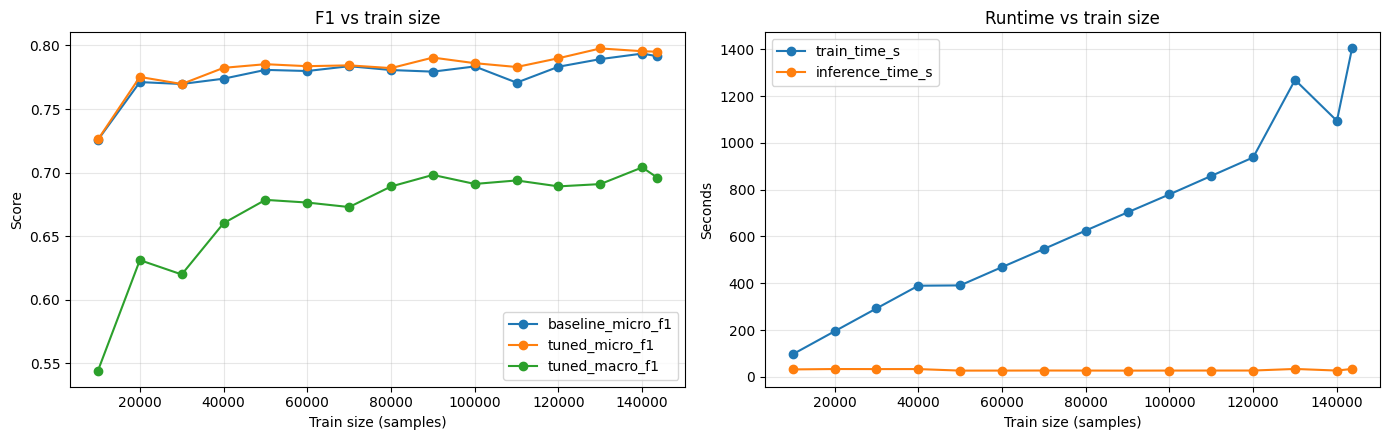

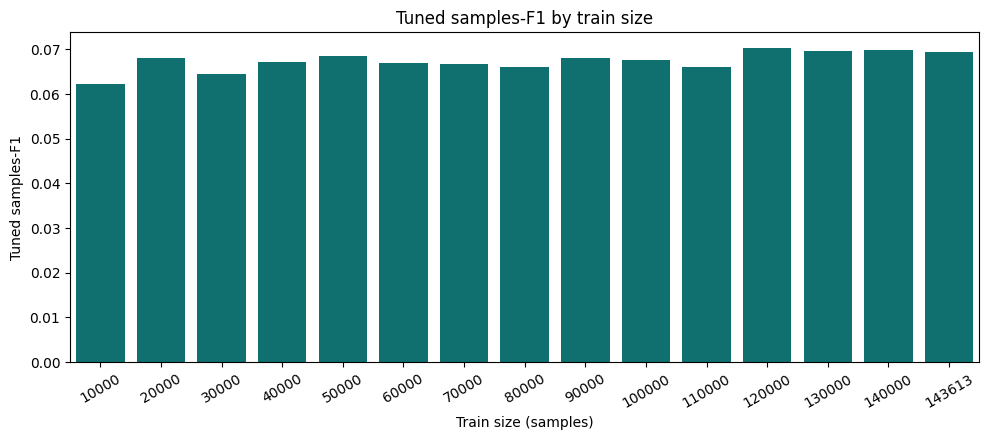

,train_size,train_fraction,actual_train_samples,tuned_micro_f1,tuned_macro_f1,tuned_samples_f1,train_time_s,inference_time_s
0,10000,0.069632,10000,0.726122,0.544405,0.062205,96.821916,32.194087
1,20000,0.139263,20000,0.775203,0.631245,0.068085,194.942425,33.854515
2,30000,0.208895,30000,0.769652,0.619975,0.064499,292.616404,33.576716
3,40000,0.278526,40000,0.782362,0.660258,0.067185,389.766473,33.661061
4,50000,0.348158,50000,0.785223,0.678600,0.068452,391.055119,27.123063
5,60000,0.417789,60000,0.783669,0.676488,0.066927,469.260113,27.224749
6,70000,0.487421,70000,0.784308,0.672952,0.066847,546.620917,27.490348
7,80000,0.557053,80000,0.782153,0.689117,0.066088,625.345718,27.315215
8,90000,0.626684,90000,0.790423,0.698210,0.067979,703.041024,27.097910
9,100000,0.696316,100000,0.786026,0.691113,0.067590,779.893068,27.303318


In [ ]:
# Graphs: performance and efficiency vs train size
if len(summary_df) > 0:
    plot_df = summary_df.sort_values('train_size').copy()

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

    axes[0].plot(plot_df['train_size'], plot_df['baseline_micro_f1'], marker='o', label='baseline_micro_f1')
    axes[0].plot(plot_df['train_size'], plot_df['tuned_micro_f1'], marker='o', label='tuned_micro_f1')
    axes[0].plot(plot_df['train_size'], plot_df['tuned_macro_f1'], marker='o', label='tuned_macro_f1')
    axes[0].set_title('F1 vs train size')
    axes[0].set_xlabel('Train size (samples)')
    axes[0].set_ylabel('Score')
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(plot_df['train_size'], plot_df['train_time_s'], marker='o', label='train_time_s')
    axes[1].plot(plot_df['train_size'], plot_df['inference_time_s'], marker='o', label='inference_time_s')
    axes[1].set_title('Runtime vs train size')
    axes[1].set_xlabel('Train size (samples)')
    axes[1].set_ylabel('Seconds')
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4.5))
    sns.barplot(data=plot_df, x='train_size', y='tuned_samples_f1', color='teal')
    plt.title('Tuned samples-F1 by train size')
    plt.xlabel('Train size (samples)')
    plt.ylabel('Tuned samples-F1')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

summary_df[['train_size', 'train_fraction', 'actual_train_samples', 'tuned_micro_f1', 'tuned_macro_f1', 'tuned_samples_f1', 'train_time_s', 'inference_time_s']].sort_values('train_size').reset_index(drop=True)